In [36]:
import pandas as pd
import numpy as np
import scipy.io as sio
import torch
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features

In [2]:
phase1_data = sio.loadmat('../data/mine_impact_data_2019.mat')
samples  = pd.DataFrame(phase1_data["x"].T)
labels  = pd.DataFrame(phase1_data["y"].T, columns=["y"])

df = pd.concat([samples, labels], axis=1, join="inner")

df = df.dropna()

In [3]:
shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

data_P1 = Extract_Features(df_X, df_Y, feature="pca", explained_variance=0.95)

print(data_P1.get_samples().shape)
print(data_P1.get_labels().shape)

data = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "amplitude_envelope",
    frame_size = 128,
    hop_length = 128
)

data_zcr = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "zero_crossing_rate",
    frame_size = 128,
    hop_length = 128
)

data_rms = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "rms_energy",
    frame_size = 128,
    hop_length = 128
)
data.X_reduced = np.concatenate((data.X_reduced, data_zcr.X_reduced, data_rms.X_reduced), axis=1)

print(data.get_samples().shape)
print(data.get_labels().shape)

(3309, 396)
(3309,)
(3309, 845)
(3309,)


In [4]:
data_P1.X_reduced = np.concatenate((data_P1.X_reduced, data.X_reduced), axis=1)

print(data_P1.get_samples().shape)
print(data_P1.get_labels().shape)


(3309, 1241)
(3309,)


[INFO] EPOCH: 1/10
Train loss: 0.549080, Train accuracy: 0.6947
[INFO] EPOCH: 2/10
Train loss: 0.440441, Train accuracy: 0.7947
[INFO] EPOCH: 3/10
Train loss: 0.353369, Train accuracy: 0.8403
[INFO] EPOCH: 4/10
Train loss: 0.282033, Train accuracy: 0.8830
[INFO] EPOCH: 5/10
Train loss: 0.214538, Train accuracy: 0.9217
[INFO] EPOCH: 6/10
Train loss: 0.165823, Train accuracy: 0.9450
[INFO] EPOCH: 7/10
Train loss: 0.125393, Train accuracy: 0.9623
[INFO] EPOCH: 8/10
Train loss: 0.089766, Train accuracy: 0.9770
[INFO] EPOCH: 9/10
Train loss: 0.066876, Train accuracy: 0.9840
[INFO] EPOCH: 10/10
Train loss: 0.049966, Train accuracy: 0.9910
[INFO] Testing the model
Test accuracy: 0.8835


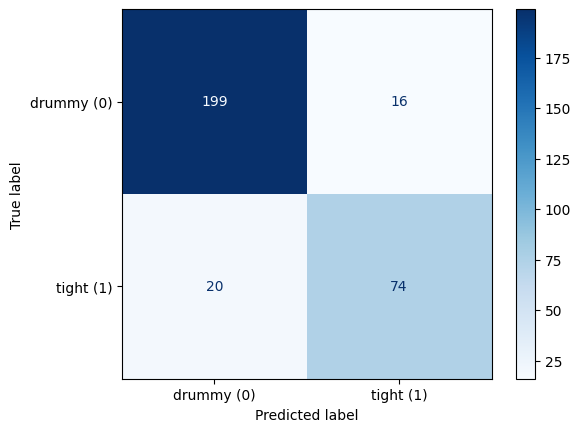


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.91      0.93      0.92       215
   tight (1)       0.82      0.79      0.80        94

    accuracy                           0.88       309
   macro avg       0.87      0.86      0.86       309
weighted avg       0.88      0.88      0.88       309



In [6]:
import models.classification as classify
import models.loops as loops

train_idx = list(range(0, 3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data_P1, train_idx)
test_data = torch.utils.data.Subset(data_P1, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = classify.MLP_2_layer(nb_hidden=512, input_dim=data_P1.get_samples().shape[1], output_dim=2, dropout_rate=0.5)

loops.train(model=model, model_path="./model_paths/pca_time.pth", train_loader=train_loader, batch_size=batch_size, lr=1e-4, weight_decay=1e-3, optim="adam", epochs=10)

loops.test(model_path="./model_paths/pca_time.pth", test_loader=test_loader,report=True)

In [2]:

phase1 = sio.loadmat('../data/mine_impact_data_2019.mat')
X_df    = pd.DataFrame(phase1["x"].T)
y_df    = pd.DataFrame(phase1["y"].T, columns=["y"])
mine_df = pd.DataFrame(phase1["mine"].T, columns=["mine"])
df = pd.concat([X_df, y_df, mine_df], axis=1).dropna().reset_index(drop=True)

df = df.dropna()

In [11]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
import models.classification as classify
import models.loops as loops
from data_classes.decomposition import Extract_Features

# --- Configuration ---
features = ["amplitude_envelope", "zero_crossing_rate", "rms_energy", "pca"]
frame_size = 128
hop_length = 128
batch_size = 30
epochs = 10

results = []
mines = sorted(df["mine"].unique())

# --- Full Feature Extraction ---
print("Extracting all features using Extract_Features class...")

# Extract all features (time-based + PCA) from full data
feature_extractors = []
for feat in features:
    if feat == "pca":
        fe = Extract_Features(
            df_X=df.iloc[:, :-2],
            df_Y=df[["y"]],
            feature=feat,
            explained_variance=0.95
        )
    else:
        fe = Extract_Features(
            df_X=df.iloc[:, :-2],
            df_Y=df[["y"]],
            feature=feat,
            frame_size=frame_size,
            hop_length=hop_length
        )
    feature_extractors.append(fe)

# Concatenate features
X_all = np.concatenate([fe.X_reduced for fe in feature_extractors], axis=1)
y_all = df["y"].values
mine_ids = df["mine"].values

# --- Leave-One-Mine-Out Evaluation ---
print("Starting Leave-One-Mine-Out Evaluation...")

print("# of features:",X_all.shape[1])

for test_mine in mines:
    test_mask = mine_ids == test_mine
    train_mask = ~test_mask

    X_train = X_all[train_mask]
    y_train = y_all[train_mask]
    X_test = X_all[test_mask]
    y_test = y_all[test_mask]

    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                  torch.tensor(y_train, dtype=torch.long))
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                 torch.tensor(y_test, dtype=torch.long))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Define model
    model = classify.MLP_3_layer(
        nb_hidden=256,
        input_dim=X_all.shape[1],
        output_dim=2,
        dropout_rate=0.5
    )

    model_path = f"./model_paths/lomo_mine_{int(test_mine)}.pth"
    loops.train(
        model=model,
        model_path=model_path,
        train_loader=train_loader,
        batch_size=batch_size,
        lr=1e-4,
        weight_decay=1e-3,
        optim="adam",
        epochs=epochs
    )

    acc = loops.test(
        model_path=model_path,
        test_loader=test_loader,
        score=True
    )

    results.append({
        "held_out_mine": int(test_mine),
        "accuracy": acc
    })
    print(f"Held-out Mine {test_mine}: Accuracy = {acc:.4f}")

# --- Results ---
results_df = pd.DataFrame(results)
print(results_df)

Extracting all features using Extract_Features class...
Starting Leave-One-Mine-Out Evaluation...
# of features: 1241
[INFO] EPOCH: 1/10
Train loss: 0.576458, Train accuracy: 0.6740
[INFO] EPOCH: 2/10
Train loss: 0.506655, Train accuracy: 0.6983
[INFO] EPOCH: 3/10
Train loss: 0.457977, Train accuracy: 0.7556
[INFO] EPOCH: 4/10
Train loss: 0.384410, Train accuracy: 0.8404
[INFO] EPOCH: 5/10
Train loss: 0.301583, Train accuracy: 0.8948
[INFO] EPOCH: 6/10
Train loss: 0.233597, Train accuracy: 0.9233
[INFO] EPOCH: 7/10
Train loss: 0.170095, Train accuracy: 0.9440
[INFO] EPOCH: 8/10
Train loss: 0.119166, Train accuracy: 0.9683
[INFO] EPOCH: 9/10
Train loss: 0.086877, Train accuracy: 0.9785
[INFO] EPOCH: 10/10
Train loss: 0.060802, Train accuracy: 0.9890
[INFO] Testing the model
Test accuracy: 0.7530
Held-out Mine 1: Accuracy = 0.7530
[INFO] EPOCH: 1/10
Train loss: 0.586834, Train accuracy: 0.6716
[INFO] EPOCH: 2/10
Train loss: 0.492733, Train accuracy: 0.7492
[INFO] EPOCH: 3/10
Train loss: 

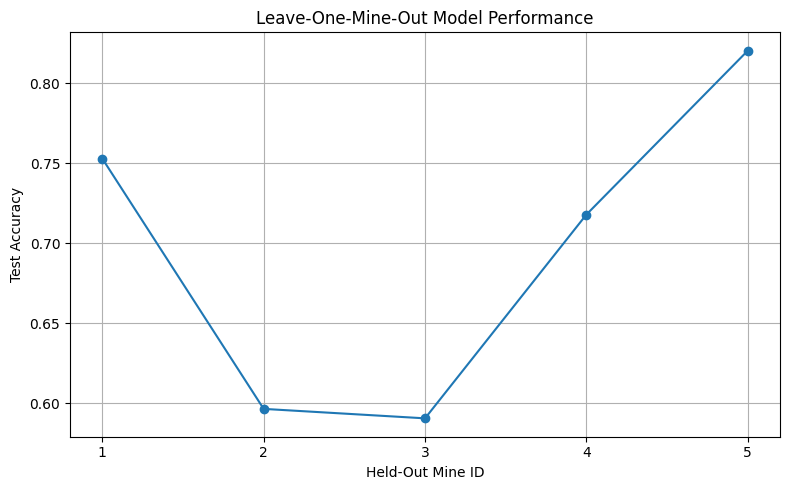

In [12]:
import matplotlib.pyplot as plt

res_df = pd.DataFrame(results)

plt.figure(figsize=(8,5))
plt.plot(res_df["held_out_mine"], res_df["accuracy"], marker='o', linestyle='-')
plt.xlabel("Held-Out Mine ID")
plt.ylabel("Test Accuracy")
plt.title("Leave-One-Mine-Out Model Performance")
plt.xticks(res_df["held_out_mine"])  # ensure each mine ID is shown on x-axis
plt.grid(True)
plt.tight_layout()
plt.show()

## Phase 2 Experimentation


In [37]:
# Load the data
data_2 = sio.loadmat('../data/phase2_data_20220215.mat')
samps_2 = pd.DataFrame(data_2['x'].T)
labs_2  = pd.DataFrame(data_2['y'].T, columns=['y'])

# Combine and drop any NaNs
df_2 = pd.concat([samps_2, labs_2], axis=1).dropna()

bad_indices = [
    100,303,496,507,609,706,909,1011,1113,1271,1373,1475,1577,1679,1781,1883,2085,2287,
    2389,2489,2789,2891,2895,2995,3096,3497,3767,3997,4099,4201,4499,4699,5199,5301,
    5302,5500,7688,7690,7691,7692,7696,7702,7704,7708,7715,7723,7727,7810,7841,7870,
    7888,7936,7941,7965,7997,8061,8080,8081,8095,8098,8124,8125,8126,8127,8128,8132,
    8156,8157,8158,8159,8160,8161,8215,8261,8302,8310,8322,8395,8425,8477,8478,8479,
    8483,8487,8491,8496,8527,8563,8587,8642,8743,8848,
    0,94,98,102,203,403,505,607,611,708,809,1009,1111,1171,1273,1473,1575,1579,1635,
    1660,1674,1681,1881,1983,1985,2087,2088,2187,2246,2387,2589,2689,2791,2893,3196,
    3455,3495,3696,3798,3999,4199,4701,4748,4749,4798,4999,5201,5209,5244,5245,5255,
    5924,5945,5977,6128,6135,6229,6271,6299,6377,6383,6388,6389,6678,6760,6903,6906,
    6935,6936,7430,7582,7694,7698,7699,7700,7706,7710,7713,7717,7718,7777,7778,7856,
    7872,7939,7943,7960,7984,7999,8046,8048,8059,8063,8064,8068,8078,8083,8084,8085,
    8093,8165,8166,8191,8308,8366,8397,8398,8481,8485,8489,8493,8494,8498,8544,8565,
    8640,8692,8798,8902
]

df_2 = df_2.drop(index=bad_indices, errors='ignore')

shuffled_df = df_2.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

In [38]:
data_P1 = Extract_Features(df_X, df_Y, feature="pca", explained_variance=0.95)

print(data_P1.get_samples().shape)
print(data_P1.get_labels().shape)

data = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "amplitude_envelope",
    frame_size = 64,
    hop_length = 64
)

data_zcr = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "zero_crossing_rate",
    frame_size = 64,
    hop_length = 64
)

data_rms = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "rms_energy",
    frame_size = 64,
    hop_length = 64
)
data.X_reduced = np.concatenate((data.X_reduced, data_zcr.X_reduced, data_rms.X_reduced), axis=1)

print(data.get_samples().shape)
print(data.get_labels().shape)

(8229, 241)
(8229,)
(8229, 227)
(8229,)


In [39]:
data_P1.X_reduced = np.concatenate((data_P1.X_reduced, data.X_reduced), axis=1)

print(data_P1.get_samples().shape)
print(data_P1.get_labels().shape)

(8229, 468)
(8229,)


[INFO] EPOCH: 1/50
Train loss: 0.807380, Train accuracy: 0.5369
Val loss: 0.804474, Val accuracy: 0.5900

[INFO] EPOCH: 2/50
Train loss: 0.713282, Train accuracy: 0.5941
Val loss: 0.747367, Val accuracy: 0.6450

[INFO] EPOCH: 3/50
Train loss: 0.665773, Train accuracy: 0.6351
Val loss: 0.725518, Val accuracy: 0.6800

[INFO] EPOCH: 4/50
Train loss: 0.645343, Train accuracy: 0.6550
Val loss: 0.708303, Val accuracy: 0.6850

[INFO] EPOCH: 5/50
Train loss: 0.616228, Train accuracy: 0.6792
Val loss: 0.699902, Val accuracy: 0.6900

[INFO] EPOCH: 6/50
Train loss: 0.592771, Train accuracy: 0.6964
Val loss: 0.686334, Val accuracy: 0.7000

[INFO] EPOCH: 7/50
Train loss: 0.574867, Train accuracy: 0.7051
Val loss: 0.674475, Val accuracy: 0.7050

[INFO] EPOCH: 8/50
Train loss: 0.566891, Train accuracy: 0.7180
Val loss: 0.660555, Val accuracy: 0.7100

[INFO] EPOCH: 9/50
Train loss: 0.546828, Train accuracy: 0.7364
Val loss: 0.653260, Val accuracy: 0.7100

[INFO] EPOCH: 10/50
Train loss: 0.533278, Trai

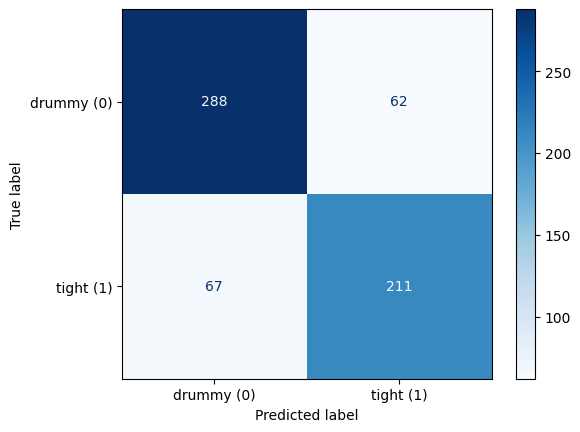


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.81      0.82      0.82       350
   tight (1)       0.77      0.76      0.77       278

    accuracy                           0.79       628
   macro avg       0.79      0.79      0.79       628
weighted avg       0.79      0.79      0.79       628



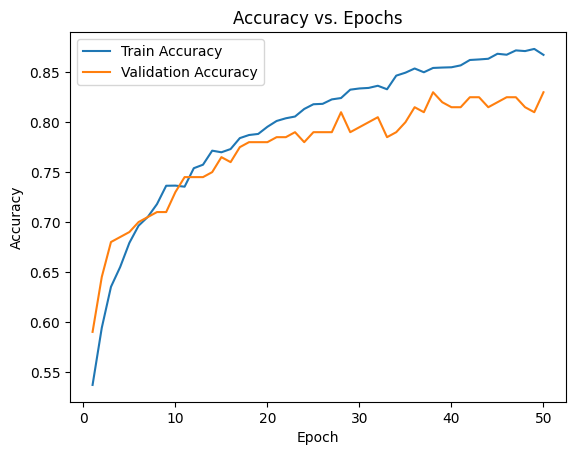

In [41]:
import matplotlib.pyplot as plt
import models.classification as classify
import models.loops as loops

train_idx = list(range(0, 7400))
val_idx = list(range(7400,7600))
test_idx = list(range(7600,8228))

train_data = torch.utils.data.Subset(data_P1, train_idx)
val_data = torch.utils.data.Subset(data_P1, val_idx)
test_data = torch.utils.data.Subset(data_P1, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)
epochs = 50
model = classify.MLP(nb_hidden=64, input_dim=data_P1.get_samples().shape[1], output_dim=2, dropout_rate=0.5)

history = loops.train(model=model, model_path="./model_paths/pca_time.pth", train_loader=train_loader,val=True,val_loader=val_loader, batch_size=batch_size, lr=1e-4, weight_decay=0, optim="adam", epochs=epochs)

loops.test(model_path="./model_paths/pca_time.pth", test_loader=test_loader,report=True)

plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
plt.title("Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()